# Feature Importance Analysis — BLR Normative Model
Analiza los patrones de importancia de features (banda × ROI) por grupo diagnóstico,
para modelos entrenados con todos los z-scores como vector de entrada.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# ── Paths ──────────────────────────────────────────────────────────────────────
SAVE_PATH = r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\AIF_Babiloni\results_harmonize\recombat\BLR_paper\bands_age\harmonized"
FAMILIES  = ['osc_pw_rel_canonic']#'osc_pw_ab_canonic']
GROUPS    = ['MCI', 'AD', 'ACr']
MODELS    = ['RF', 'SVM', 'LogReg', 'DT']
BANDS     = ['theta', 'alpha1', 'alpha2', 'beta1', 'beta2', 'beta3', 'gamma']
ROIS      = ['F', 'C', 'P', 'O', 'PO']

# ── Load feature importance files ─────────────────────────────────────────────
imp_dfs = []
for family in FAMILIES:
    for group in GROUPS:
        fpath = os.path.join(SAVE_PATH, f"feature_importance_{family}_{group}.csv")
        if not os.path.exists(fpath):
            print(f"Missing: {fpath}")
            continue
        df = pd.read_csv(fpath)
        df['family']      = family
        df['group_vs_HC'] = group
        imp_dfs.append(df)

imp = pd.concat(imp_dfs, ignore_index=True)
imp['imp_norm'] = imp.groupby(['family', 'group_vs_HC', 'model'])['importance'].transform(
    lambda x: x / x.sum() if x.sum() > 0 else x
)

# ── Load model performance files ──────────────────────────────────────────────
perf_dfs = []
for family in FAMILIES:
    for group in GROUPS:
        fpath = os.path.join(SAVE_PATH, f"SVM_allFeatures_{family}_{group}.csv")
        if not os.path.exists(fpath):
            print(f"Missing perf: {fpath}")
            continue
        df = pd.read_csv(fpath)
        df['family']      = family
        df['group_vs_HC'] = group
        perf_dfs.append(df)

perf = pd.concat(perf_dfs, ignore_index=True)
print(f"Importance rows: {len(imp)} | Performance rows: {len(perf)}")
print(f"Families: {imp['family'].unique().tolist()}")
print(f"Groups:   {imp['group_vs_HC'].unique().tolist()}")

Importance rows: 480 | Performance rows: 12
Families: ['osc_pw_rel_canonic']
Groups:   ['MCI', 'AD', 'ACr']


## 0. Selección del mejor modelo
Antes de analizar importancias, comparamos AUC (CV) y AUC bootstrap de los 4 modelos
para cada grupo y familia. El modelo con mejor AUC promedio global se usará en todo el análisis posterior.

=== Comparación de modelos (promedio sobre todos los grupos) ===


,family,model,AUC_mean,AUC_std,boot_AUC_mean,boot_AUC_std,brier,AUC_gap
2,osc_pw_rel_canonic,RF,0.865,0.090,0.871,0.052,0.160,-0.006
0,osc_pw_rel_canonic,DT,0.742,0.099,0.692,0.094,0.273,0.050
1,osc_pw_rel_canonic,LogReg,0.734,0.062,0.723,0.088,0.220,0.011
3,osc_pw_rel_canonic,SVM,0.693,0.060,0.711,0.091,0.227,-0.018


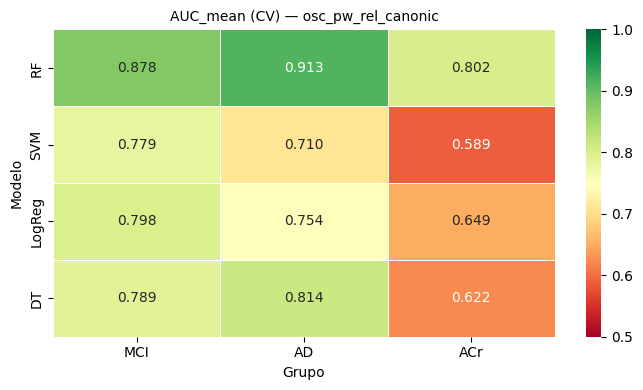

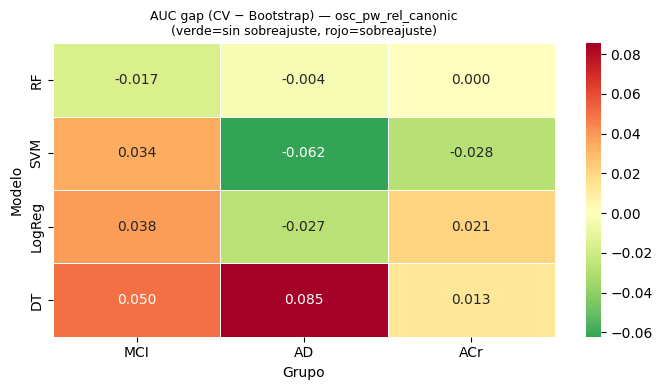


osc_pw_rel_canonic:
model
RF        0.871
LogReg    0.723
SVM       0.711
DT        0.692
  → Mejor modelo: RF

✔ FAMILY = osc_pw_rel_canonic
✔ BEST_MODEL = RF  ← se usará en todas las secciones siguientes


In [2]:
# ── Tabla comparativa de modelos: AUC_mean, AUC_std, boot_AUC_mean, brier ──────
model_comparison = (
    perf.groupby(['family', 'model'])[['AUC_mean', 'AUC_std', 'boot_AUC_mean', 'boot_AUC_std', 'brier']]
    .mean()
    .round(3)
    .reset_index()
)
model_comparison['AUC_gap'] = (model_comparison['AUC_mean'] - model_comparison['boot_AUC_mean']).round(3)

print("=== Comparación de modelos (promedio sobre todos los grupos) ===")
display(model_comparison.sort_values(['family', 'AUC_mean'], ascending=[True, False]))

# ── Heatmap AUC por modelo × grupo (por familia) ──────────────────────────────
fig, axes = plt.subplots(1, len(FAMILIES), figsize=(7 * len(FAMILIES), 4))
if len(FAMILIES) == 1:
    axes = [axes]

for ax, family in zip(axes, FAMILIES):
    pivot = perf[perf['family'] == family].pivot_table(
        index='model', columns='group_vs_HC', values='AUC_mean'
    )
    pivot = pivot.reindex(index=MODELS, columns=GROUPS)
    sns.heatmap(pivot, ax=ax, cmap='RdYlGn', annot=True, fmt='.3f',
                linewidths=0.5, vmin=0.5, vmax=1.0, cbar=True)
    ax.set_title(f'AUC_mean (CV) — {family}', fontsize=10)
    ax.set_xlabel('Grupo')
    ax.set_ylabel('Modelo')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'model_comparison_heatmap.png'), dpi=200, bbox_inches='tight')
plt.show()

# ── Heatmap Bootstrap AUC gap (CV - bootstrap): indica sobreajuste ────────────
fig, axes = plt.subplots(1, len(FAMILIES), figsize=(7 * len(FAMILIES), 4))
if len(FAMILIES) == 1:
    axes = [axes]

for ax, family in zip(axes, FAMILIES):
    df_fam = perf[perf['family'] == family].copy()
    df_fam['gap'] = df_fam['AUC_mean'] - df_fam['boot_AUC_mean']
    pivot_gap = df_fam.pivot_table(index='model', columns='group_vs_HC', values='gap')
    pivot_gap = pivot_gap.reindex(index=MODELS, columns=GROUPS)
    sns.heatmap(pivot_gap, ax=ax, cmap='RdYlGn_r', annot=True, fmt='.3f',
                linewidths=0.5, center=0, cbar=True)
    ax.set_title(f'AUC gap (CV − Bootstrap) — {family}\n(verde=sin sobreajuste, rojo=sobreajuste)', fontsize=9)
    ax.set_xlabel('Grupo')
    ax.set_ylabel('Modelo')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'model_overfitting_gap.png'), dpi=200, bbox_inches='tight')
plt.show()

# ── Selección automática del mejor modelo por familia ─────────────────────────
# Criterio: mayor boot_AUC_mean (más conservador que CV) promedio sobre grupos
best_models = {}
for family in FAMILIES:
    df_fam = perf[perf['family'] == family]
    score = df_fam.groupby('model')['boot_AUC_mean'].mean()
    best_models[family] = score.idxmax()
    print(f"\n{family}:")
    print(score.sort_values(ascending=False).round(3).to_string())
    print(f"  → Mejor modelo: {best_models[family]}")

# Variable global: mejor modelo para la familia principal de análisis
FAMILY     = 'osc_pw_rel_canonic'   # ← cambiar aquí si quieres analizar la otra familia
BEST_MODEL = best_models[FAMILY]
print(f"\n✔ FAMILY = {FAMILY}")
print(f"✔ BEST_MODEL = {BEST_MODEL}  ← se usará en todas las secciones siguientes")

## 1. Top features por grupo — Tabla resumen
Para cada grupo diagnóstico y modelo, las N features más importantes (banda × ROI).

In [3]:
# FAMILY y BEST_MODEL vienen de la celda 0 — no cambiar aquí
TOP_N = 10

df_sel = imp[(imp['family'] == FAMILY) & (imp['model'] == BEST_MODEL)].copy()

summary_rows = []
for group in GROUPS:
    df_g = df_sel[df_sel['group_vs_HC'] == group].copy()
    if df_g.empty:
        continue
    df_g = df_g.sort_values('importance', ascending=False).head(TOP_N)
    df_g['rank'] = range(1, len(df_g) + 1)
    df_g['feature_label'] = df_g['band'].fillna('exponent') + ' — ' + df_g['roi']
    summary_rows.append(df_g[['group_vs_HC', 'rank', 'feature_label', 'band', 'roi',
                               'importance', 'imp_norm', 'fold_votes', 'stable']])

df_summary = pd.concat(summary_rows, ignore_index=True)

pivot_top = df_summary[df_summary['rank'] == 1].pivot_table(
    index='feature_label', columns='group_vs_HC', values='importance', aggfunc='mean'
)
print(f"Top-1 feature por grupo  ({FAMILY} | modelo={BEST_MODEL}):")
display(pivot_top)

print(f"\nTop-{TOP_N} features por grupo:")
display(df_summary.sort_values(['group_vs_HC', 'rank']))

Top-1 feature por grupo  (osc_pw_rel_canonic | modelo=RF):


group_vs_HC,ACr,AD,MCI
feature_label,,,
gamma — O,0.130321,NaN,NaN
theta — C,NaN,0.212661,0.148077



Top-10 features por grupo:


,group_vs_HC,rank,feature_label,band,roi,importance,imp_norm,fold_votes,stable
20,ACr,1,gamma — O,gamma,O,0.130321,0.130321,2,True
21,ACr,2,beta1 — P,beta1,P,0.108133,0.108133,2,True
22,ACr,3,beta3 — PO,beta3,PO,0.107339,0.107339,2,True
23,ACr,4,alpha1 — F,alpha1,F,0.094414,0.094414,3,True
24,ACr,5,beta3 — O,beta3,O,0.091974,0.091974,2,True
25,ACr,6,beta1 — C,beta1,C,0.073646,0.073646,3,True
26,ACr,7,gamma — C,gamma,C,0.059627,0.059627,3,True
27,ACr,8,theta — C,theta,C,0.047112,0.047112,3,True
28,ACr,9,beta3 — F,beta3,F,0.046418,0.046418,1,False
29,ACr,10,alpha2 — F,alpha2,F,0.034077,0.034077,1,False


## 2. Heatmap: Importancia por banda × ROI para cada grupo
Una figura por grupo, mostrando qué banda y ROI domina.

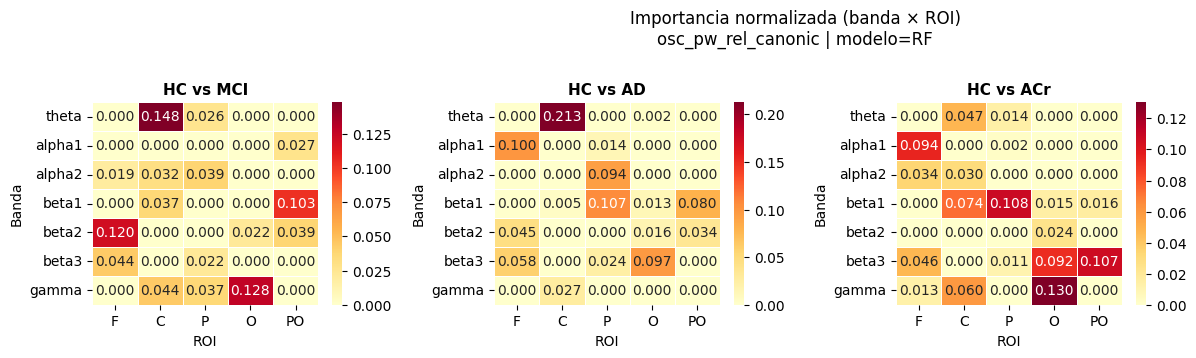

In [4]:
# FAMILY y BEST_MODEL vienen de la celda 0
df_sel = imp[(imp['family'] == FAMILY) & (imp['model'] == BEST_MODEL)].copy()
df_sel = df_sel[df_sel['band'].isin(BANDS)]   # excluir 'exponent' en esta vista

ncols = 4
nrows = int(np.ceil(len(GROUPS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5))
axes = axes.flatten()

for i, group in enumerate(GROUPS):
    ax = axes[i]
    df_g = df_sel[df_sel['group_vs_HC'] == group].copy()
    if df_g.empty:
        ax.set_visible(False)
        continue
    pivot = df_g.pivot_table(index='band', columns='roi', values='imp_norm', aggfunc='mean')
    pivot = pivot.reindex(index=[b for b in BANDS if b in pivot.index],
                          columns=[r for r in ROIS if r in pivot.columns])
    sns.heatmap(pivot, ax=ax, cmap='YlOrRd', annot=True, fmt='.3f',
                linewidths=0.5, cbar=True, vmin=0)
    ax.set_title(f'HC vs {group}', fontsize=11, fontweight='bold')
    ax.set_xlabel('ROI')
    ax.set_ylabel('Banda')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f'Importancia normalizada (banda × ROI)\n{FAMILY} | modelo={BEST_MODEL}',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, f'heatmap_importance_{FAMILY}_{BEST_MODEL}.png'),
            dpi=200, bbox_inches='tight')
plt.show()

## 3. Importancia por banda — comparación entre grupos
¿Theta domina en todos los grupos o es específico de alguno?

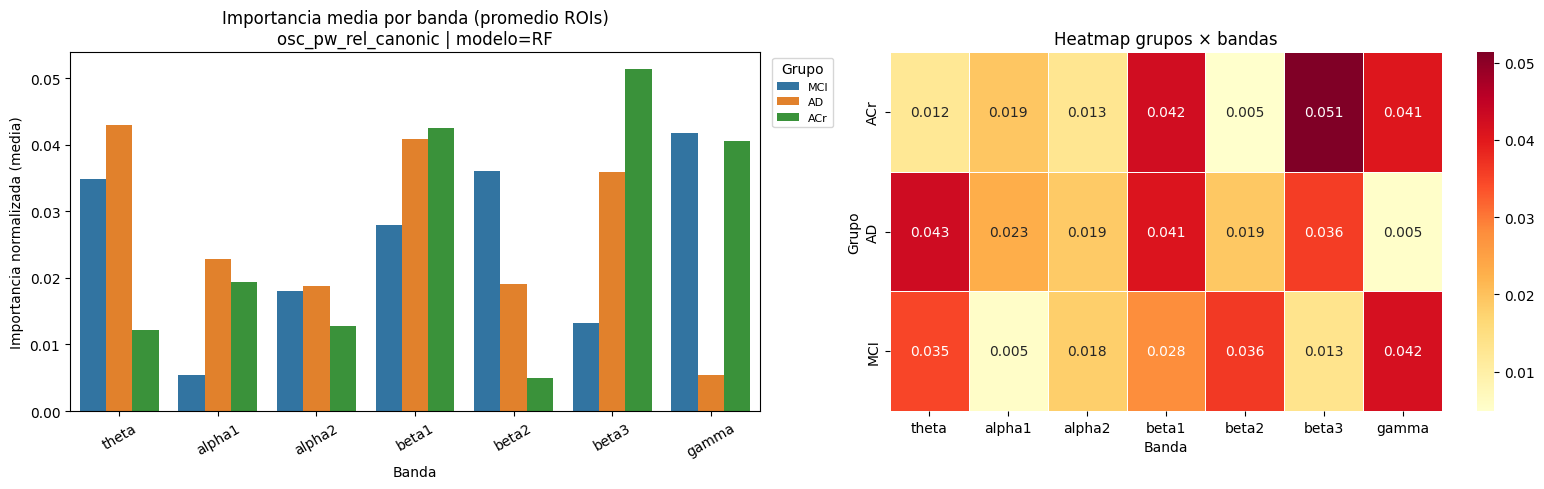


Top banda por grupo  (modelo=RF):


,Grupo,Top banda,Importancia
0,ACr,beta3,0.051372
1,AD,theta,0.042943
2,MCI,gamma,0.041815


In [5]:
# FAMILY y BEST_MODEL vienen de la celda 0
df_sel = imp[
    (imp['family'] == FAMILY) &
    (imp['model']  == BEST_MODEL) &
    (imp['band'].isin(BANDS))
].copy()

band_group = (
    df_sel.groupby(['group_vs_HC', 'band'])['imp_norm']
    .mean().reset_index()
)
band_group['band'] = pd.Categorical(band_group['band'], categories=BANDS, ordered=True)
band_group = band_group.sort_values('band')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
sns.barplot(data=band_group, x='band', y='imp_norm', hue='group_vs_HC',
            palette='tab10', ax=ax)
ax.set_title(f'Importancia media por banda (promedio ROIs)\n{FAMILY} | modelo={BEST_MODEL}')
ax.set_xlabel('Banda')
ax.set_ylabel('Importancia normalizada (media)')
ax.legend(title='Grupo', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.tick_params(axis='x', rotation=30)

ax2 = axes[1]
pivot_band = band_group.pivot(index='group_vs_HC', columns='band', values='imp_norm')
pivot_band = pivot_band[[b for b in BANDS if b in pivot_band.columns]]
sns.heatmap(pivot_band, ax=ax2, cmap='YlOrRd', annot=True, fmt='.3f',
            linewidths=0.5, cbar=True)
ax2.set_title('Heatmap grupos × bandas')
ax2.set_xlabel('Banda')
ax2.set_ylabel('Grupo')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, f'band_importance_by_group_{FAMILY}_{BEST_MODEL}.png'),
            dpi=200, bbox_inches='tight')
plt.show()

top_band = band_group.loc[band_group.groupby('group_vs_HC')['imp_norm'].idxmax(),
                          ['group_vs_HC', 'band', 'imp_norm']]
top_band.columns = ['Grupo', 'Top banda', 'Importancia']
print(f"\nTop banda por grupo  (modelo={BEST_MODEL}):")
display(top_band.reset_index(drop=True))

## 4. Importancia por ROI — comparación entre grupos
¿Hay regiones topográficas específicas por patología?

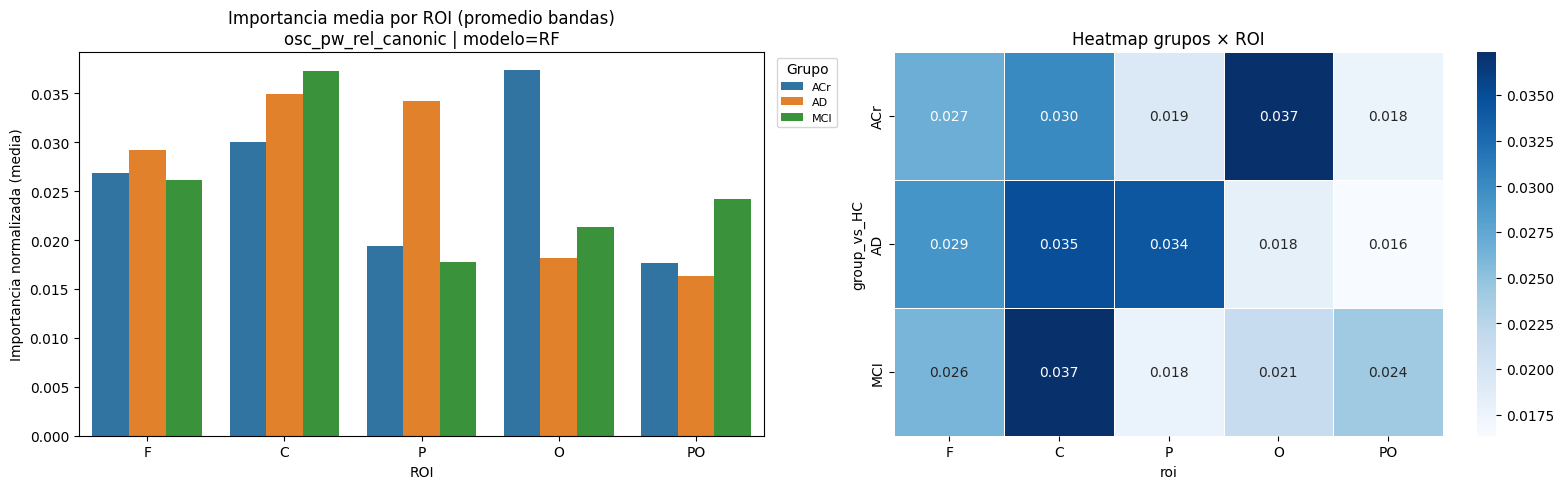


Top ROI por grupo  (modelo=RF):


,Grupo,Top ROI,Importancia
0,ACr,O,0.037346
1,AD,C,0.034891
2,MCI,C,0.037301


In [6]:
# FAMILY y BEST_MODEL vienen de la celda 0
df_sel = imp[
    (imp['family'] == FAMILY) &
    (imp['model']  == BEST_MODEL) &
    (imp['band'].isin(BANDS))
].copy()

roi_group = (
    df_sel.groupby(['group_vs_HC', 'roi'])['imp_norm']
    .mean().reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
sns.barplot(data=roi_group, x='roi', y='imp_norm', hue='group_vs_HC',
            palette='tab10', ax=ax, order=ROIS)
ax.set_title(f'Importancia media por ROI (promedio bandas)\n{FAMILY} | modelo={BEST_MODEL}')
ax.set_xlabel('ROI')
ax.set_ylabel('Importancia normalizada (media)')
ax.legend(title='Grupo', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

ax2 = axes[1]
pivot_roi = roi_group.pivot(index='group_vs_HC', columns='roi', values='imp_norm')
pivot_roi = pivot_roi[[r for r in ROIS if r in pivot_roi.columns]]
sns.heatmap(pivot_roi, ax=ax2, cmap='Blues', annot=True, fmt='.3f',
            linewidths=0.5, cbar=True)
ax2.set_title('Heatmap grupos × ROI')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, f'roi_importance_by_group_{FAMILY}_{BEST_MODEL}.png'),
            dpi=200, bbox_inches='tight')
plt.show()

top_roi = roi_group.loc[roi_group.groupby('group_vs_HC')['imp_norm'].idxmax(),
                        ['group_vs_HC', 'roi', 'imp_norm']]
top_roi.columns = ['Grupo', 'Top ROI', 'Importancia']
print(f"\nTop ROI por grupo  (modelo={BEST_MODEL}):")
display(top_roi.reset_index(drop=True))

## 5. Estabilidad de features — fold votes
Features que aparecen en ≥50% de los folds (`stable=True`) son robustas.
¿Theta aparece consistentemente o es inestable?

C:\Users\luisa\AppData\Local\Temp\ipykernel_260\3563453910.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stable_band, x='band', y='n_stable', palette='Greens_d', ax=ax2)


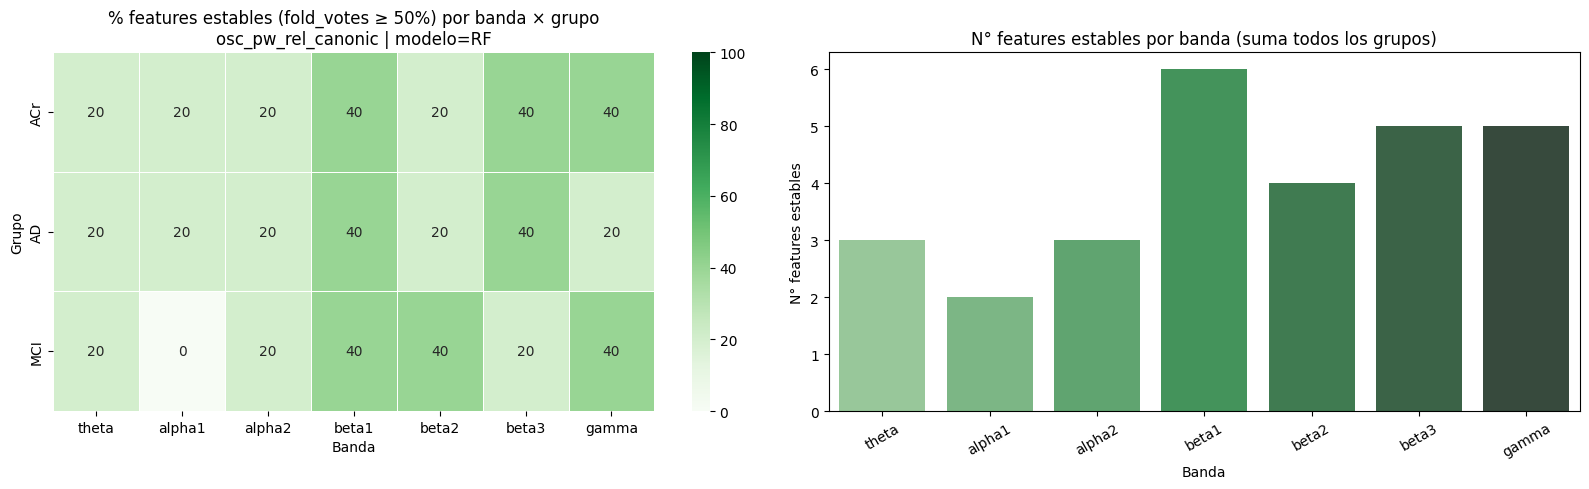


Total features estables por banda:
  band  n_stable
 theta         3
alpha1         2
alpha2         3
 beta1         6
 beta2         4
 beta3         5
 gamma         5


In [7]:
# FAMILY y BEST_MODEL vienen de la celda 0
df_sel = imp[
    (imp['family'] == FAMILY) &
    (imp['model']  == BEST_MODEL) &
    (imp['band'].isin(BANDS))
].copy()

stable_pct = (
    df_sel.groupby(['group_vs_HC', 'band'])['stable']
    .mean().mul(100).reset_index()
    .rename(columns={'stable': 'pct_stable'})
)
stable_pct['band'] = pd.Categorical(stable_pct['band'], categories=BANDS, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
pivot_stable = stable_pct.pivot(index='group_vs_HC', columns='band', values='pct_stable')
pivot_stable = pivot_stable[[b for b in BANDS if b in pivot_stable.columns]]
sns.heatmap(pivot_stable, ax=ax, cmap='Greens', annot=True, fmt='.0f',
            linewidths=0.5, cbar=True, vmin=0, vmax=100)
ax.set_title(f'% features estables (fold_votes ≥ 50%) por banda × grupo\n{FAMILY} | modelo={BEST_MODEL}')
ax.set_xlabel('Banda')
ax.set_ylabel('Grupo')

ax2 = axes[1]
stable_band = (
    df_sel[df_sel['stable'] == True]
    .groupby('band').size()
    .reindex(BANDS, fill_value=0).reset_index()
    .rename(columns={0: 'n_stable'})
)
sns.barplot(data=stable_band, x='band', y='n_stable', palette='Greens_d', ax=ax2)
ax2.set_title('N° features estables por banda (suma todos los grupos)')
ax2.set_xlabel('Banda')
ax2.set_ylabel('N° features estables')
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, f'stability_by_band_{FAMILY}_{BEST_MODEL}.png'),
            dpi=200, bbox_inches='tight')
plt.show()
print(f"\nTotal features estables por banda:\n{stable_band.to_string(index=False)}")

## 6. Comparación entre familias (osc vs pw)
¿El patrón de importancia cambia cuando se usa potencia oscilatoria vs potencia total?

C:\Users\luisa\AppData\Local\Temp\ipykernel_260\541503382.py:19: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.barplot(data=df_g, x='band', y='imp_norm', hue='family',
C:\Users\luisa\AppData\Local\Temp\ipykernel_260\541503382.py:19: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.barplot(data=df_g, x='band', y='imp_norm', hue='family',
C:\Users\luisa\AppData\Local\Temp\ipykernel_260\541503382.py:19: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.barplot(data=df_g, x='band', y='imp_norm', hue='family',


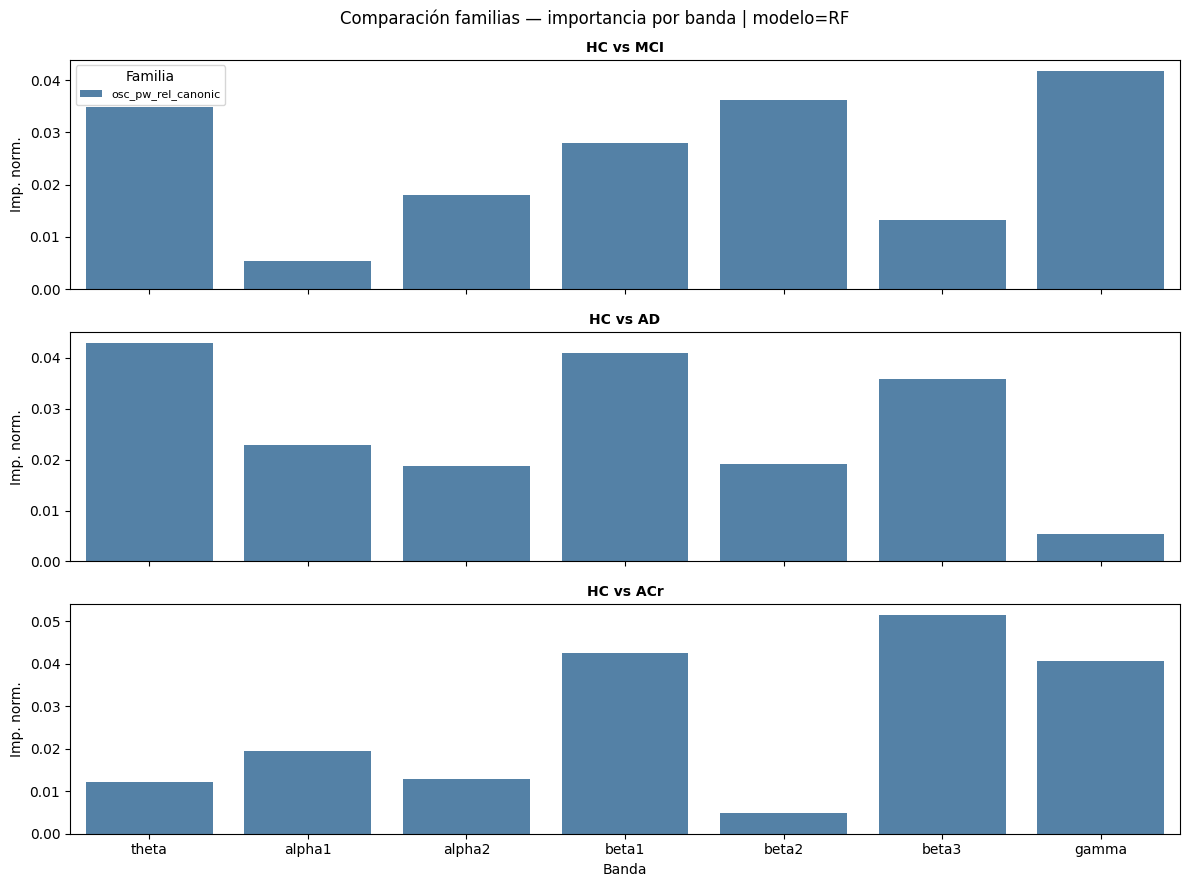

In [8]:
# BEST_MODEL viene de la celda 0
df_sel = imp[
    (imp['model'] == BEST_MODEL) &
    (imp['band'].isin(BANDS))
].copy()

band_family = (
    df_sel.groupby(['family', 'group_vs_HC', 'band'])['imp_norm']
    .mean().reset_index()
)
band_family['band'] = pd.Categorical(band_family['band'], categories=BANDS, ordered=True)

n_groups = len(GROUPS)
fig, axes = plt.subplots(n_groups, 1, figsize=(12, n_groups * 3), sharex=True)

for i, group in enumerate(GROUPS):
    ax = axes[i]
    df_g = band_family[band_family['group_vs_HC'] == group]
    sns.barplot(data=df_g, x='band', y='imp_norm', hue='family',
                palette=['steelblue', 'coral'], ax=ax, order=BANDS)
    ax.set_title(f'HC vs {group}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Imp. norm.')
    ax.set_xlabel('')
    if i == 0:
        ax.legend(title='Familia', fontsize=8)
    else:
        ax.get_legend().remove()

axes[-1].set_xlabel('Banda')
fig.suptitle(f'Comparación familias — importancia por banda | modelo={BEST_MODEL}', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, f'family_comparison_band_{BEST_MODEL}.png'),
            dpi=200, bbox_inches='tight')
plt.show()

## 7. Exportar tabla resumen para el paper
Tabla con top features estables por grupo, para incluir en el manuscrito.

In [9]:
# FAMILY y BEST_MODEL vienen de la celda 0
TOP_N = 5

df_sel = imp[
    (imp['family'] == FAMILY) &
    (imp['model']  == BEST_MODEL) &
    (imp['band'].isin(BANDS))
].copy()

paper_rows = []
for group in GROUPS:
    df_g = df_sel[df_sel['group_vs_HC'] == group].copy()
    if df_g.empty:
        continue
    df_g = df_g.sort_values(['stable', 'importance'], ascending=[False, False]).head(TOP_N)
    df_g['Rank']    = range(1, len(df_g) + 1)
    df_g['Feature'] = df_g['band'] + ' (' + df_g['roi'] + ')'
    df_g['Group']   = group
    paper_rows.append(df_g[['Group', 'Rank', 'Feature', 'band', 'roi',
                              'importance', 'imp_norm', 'fold_votes', 'stable']])

df_paper = pd.concat(paper_rows, ignore_index=True)

out_excel = os.path.join(SAVE_PATH, f'paper_feature_importance_{FAMILY}_{BEST_MODEL}.xlsx')
with pd.ExcelWriter(out_excel) as writer:
    df_paper.to_excel(writer, sheet_name='all_groups', index=False)
    for group in GROUPS:
        df_g = df_paper[df_paper['Group'] == group]
        if not df_g.empty:
            df_g.to_excel(writer, sheet_name=group, index=False)

print(f"Guardado: {out_excel}")
print(f"Modelo usado: {BEST_MODEL} | Familia: {FAMILY}")
display(df_paper)

Guardado: D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\AIF_Babiloni\results_harmonize\recombat\BLR_paper\bands_age\harmonized\paper_feature_importance_osc_pw_rel_canonic_RF.xlsx
Modelo usado: RF | Familia: osc_pw_rel_canonic


,Group,Rank,Feature,band,roi,importance,imp_norm,fold_votes,stable
0,MCI,1,theta (C),theta,C,0.148077,0.148077,4,True
1,MCI,2,gamma (O),gamma,O,0.127705,0.127705,3,True
2,MCI,3,beta2 (F),beta2,F,0.120038,0.120038,2,True
3,MCI,4,beta1 (PO),beta1,PO,0.103277,0.103277,2,True
4,MCI,5,gamma (C),gamma,C,0.044430,0.044430,3,True
5,AD,1,theta (C),theta,C,0.212661,0.212661,4,True
6,AD,2,beta1 (P),beta1,P,0.107083,0.107083,2,True
7,AD,3,alpha1 (F),alpha1,F,0.100419,0.100419,3,True
8,AD,4,beta3 (O),beta3,O,0.096723,0.096723,2,True
9,AD,5,alpha2 (P),alpha2,P,0.093814,0.093814,2,True
